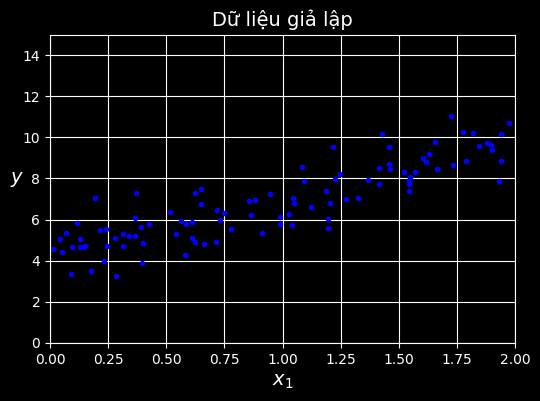

In [2]:
import sys

from sklearn.linear_model import LinearRegression

assert sys.version_info >= (3, 7)

import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

np.random.seed(42)

m = 100  # số mẫu
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

# Vẽ dữ liệu
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.title("Dữ liệu giả lập")
plt.show()


Giai 1a

In [3]:
x_b = sklearn.preprocessing.add_dummy_feature(X)
theta_best = np.linalg.inv(x_b.T@x_b)@x_b.T@y
print("theta_best =", theta_best)

theta_best = [[4.21509616]
 [2.77011339]]


Giai 1b

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print("Intercept:", lin_reg.intercept_)
print("Coef:", lin_reg.coef_)

Intercept: [4.21509616]
Coef: [[2.77011339]]


Giai 1c

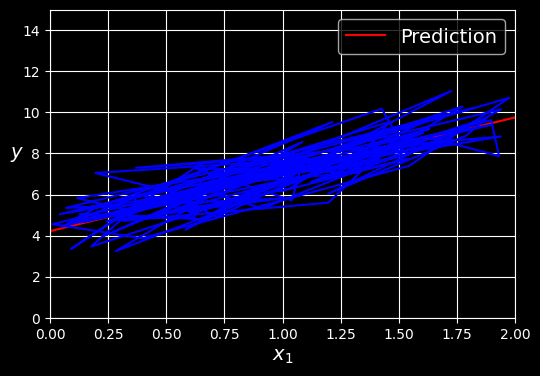

In [5]:
X_new = np.array([[0], [2]])
y_predict = lin_reg.predict(X_new)

plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, "r-", label = "Prediction")
plt.plot(X, y, "b")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend()
plt.show()

Bai 2a

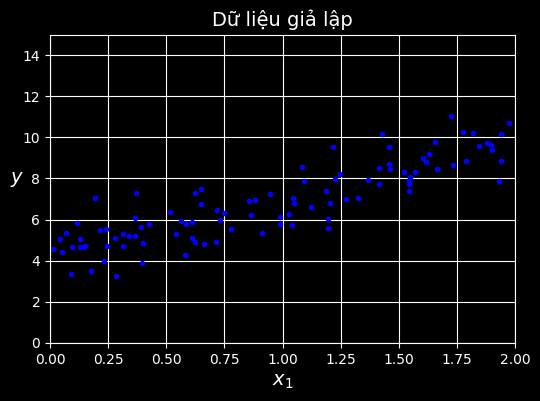

theta_best = [[4.21509616]
 [2.77011339]]
Intercept: [4.21509616]
Coef: [[2.77011339]]


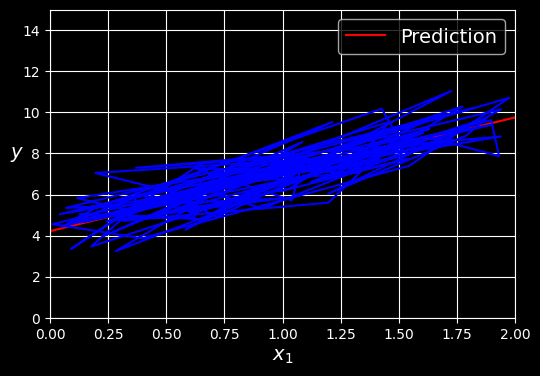

theta = [[4.21509616]
 [2.77011339]]


In [6]:
from bai1 import x_b, y, X
import numpy as np
import matplotlib as mpl
import sklearn.preprocessing
import matplotlib.pyplot as plt




#Bai 2a
eta = 0.1  # learning rate
n_epochs = 1000
m = len(x_b)  # đảm bảo X_b đã được tạo ở Bài 1a

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):

    gradients = 2/m * x_b.T @ (x_b @ theta - y)
    theta = theta - eta * gradients
    pass

print("theta =", theta)


2B

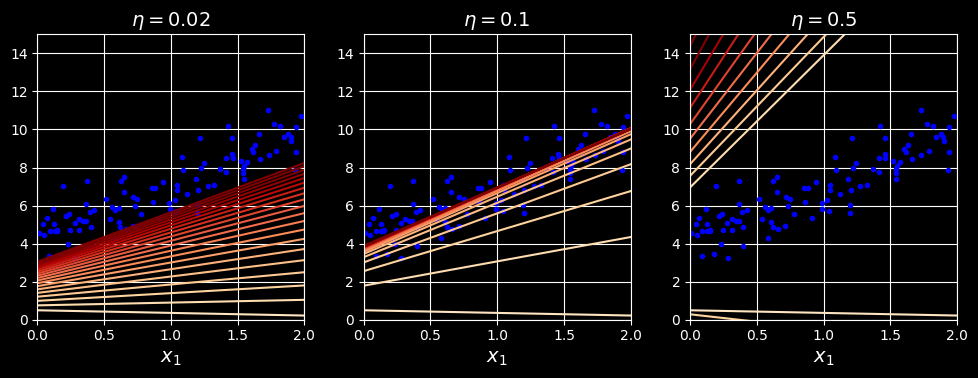

In [7]:
X_new = np.array([[0], [2]])
X_new_b = sklearn.preprocessing.add_dummy_feature(X_new)

def plot_gradient_descent(theta, eta):
    m = len(x_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20

    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)

        # YOUR CODE HERE — tính gradients và cập nhật theta
        gradients = 2/m * x_b.T @ (x_b @ theta - y)
        theta = theta - eta * gradients
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")

np.random.seed(42)
theta = np.random.randn(2, 1)

plt.figure(figsize=(10, 4))
# YOUR CODE HERE — vẽ 3 subplot với eta = 0.02, 0.1, 0.5

plt.subplot(1, 3, 1)
plot_gradient_descent(theta, eta=0.02)

plt.subplot(1, 3, 2)
plot_gradient_descent(theta, eta=0.1)

plt.subplot(1, 3, 3)
plot_gradient_descent(theta, eta=0.5)

plt.tight_layout()

plt.show()

Bai 3a


theta = [[4.21509616]
 [2.77011339]]


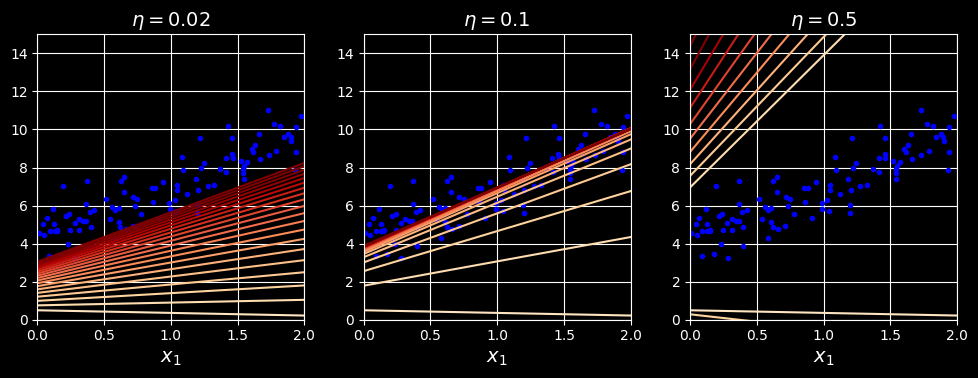

SGD theta = [[4.21075261]
 [2.74857242]]


In [8]:
from bai1 import x_b, y, X
from bai2 import m
import numpy as np
from sklearn.linear_model import SGDRegressor

import matplotlib as mpl
import sklearn.preprocessing
import matplotlib.pyplot as plt

#Bai 3a

n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)

t = 0

for epoch in range(n_epochs):
    for iteration in range(m):
        # YOUR CODE HERE
        random_index = np.random.randint(m)

        #cắt lát từng mẻ một
        xi = x_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # công thức sgd thì k chia gradient cho m
        # t là tổng số bước lặp đã thực hiện từ đầu đến giờ
        t += 1
        eta = learning_schedule(t)
        theta = theta - eta * gradients


print("SGD theta =", theta)

Bai 3b

In [9]:
sgd_reg = SGDRegressor(max_iter=1000, tol = 1e-5, penalty= None, eta0=0.01, n_iter_no_change=100, random_state = 42)
sgd_reg.fit(X, y.ravel())

print("intercept:", sgd_reg.intercept_)
print("coef:", sgd_reg.coef_)

intercept: [4.21278812]
coef: [2.77270267]


Bai 4a

In [10]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np


# Iris dataset có sẵn trong sklearn, không cần download
iris = load_iris(as_frame=True)
print("Feature names:", list(iris.data.columns))
print("Target names:", list(iris.target_names))
print("Shape:", iris.data.shape)

#Bai 4a
X_iris =  iris["data"][["petal width (cm)"]].values
y_iris = (iris["target"]== 2).astype(int) #astype(int) de chuyen ve 0 va 1

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_iris, y_iris)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Shape: (150, 4)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Bai 4b

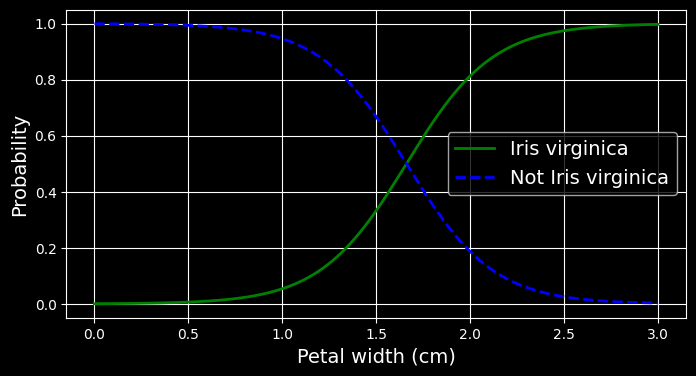

In [11]:
X_new_iris = np.linspace(0,3,1000).reshape(-1, 1)

y_proba = log_reg.predict_proba(X_new_iris)

plt.figure(figsize=(8, 4))
plt.plot(X_new_iris, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica")
plt.plot(X_new_iris, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend()
plt.grid()
plt.show()

Bai 4c

In [12]:
X_test = np.array([[1.7], [2.0]])
predict = log_reg.predict(X_test)
proba = log_reg.predict_proba(X_test)

for i in range(len(X_test)):
    width = X_test[i][0]
    cls = "Iris-Virginica" if predict[i] == 1 else "Not Virginica"
    prob = proba[i][1] * 100

print("Pental width: ", width)
print("Xac saut la Virginica: ", prob)



Pental width:  2.0
Xac saut la Virginica:  81.3303254981824


Bai 5a

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Shape: (150, 4)


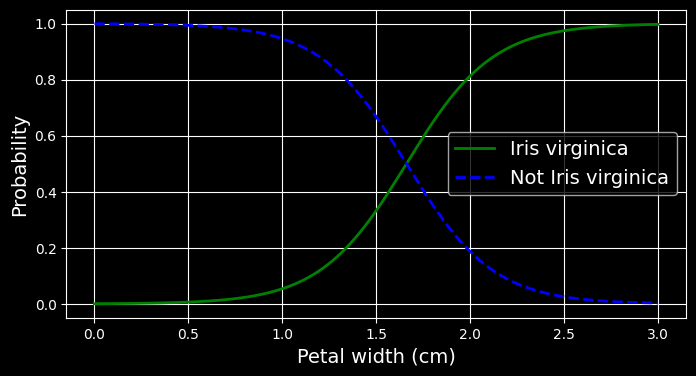

Pental width:  2.0
Xac saut la Virginica:  81.3303254981824


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [13]:
from bai4 import iris
from sklearn.linear_model import LogisticRegression
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


#Bai 5a

X_softmax = iris["data"][["petal length (cm)", "petal width (cm)"]].values
y_softmax = iris["target"].values

softmax_reg = LogisticRegression(solver="lbfgs", C=10, random_state=42)
softmax_reg.fit(X_softmax, y_softmax)

Bai 5b

In [ ]:
sample = np.array([[5,2]])
print("Predicted class:", softmax_reg.predict(sample))
print("Probabilities:", softmax_reg.predict_proba(sample))


custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0_grid = np.linspace(0, 7, 500)      # Trục hoành (Petal length) từ 0 đến 7
x1_grid = np.linspace(0, 3.5, 200)    # Trục tung (Petal width) từ 0 đến 3.5
x0_mesh, x1_mesh = np.meshgrid(x0_grid, x1_grid)

X_grid = np.c_[x0_mesh.ravel(), x1_mesh.ravel()]

y_pred_grid = softmax_reg.predict(X_grid).reshape(x0_mesh.shape)

plt.figure(figsize=(10, 6))

plt.contourf(x0_mesh, x1_mesh, y_pred_grid, cmap=custom_cmap, alpha=0.8)

plt.plot(X_softmax[y_softmax==0, 0], X_softmax[y_softmax==0, 1], "yo", label="Iris setosa")
plt.plot(X_softmax[y_softmax==1, 0], X_softmax[y_softmax==1, 1], "bs", label="Iris versicolor")
plt.plot(X_softmax[y_softmax==2, 0], X_softmax[y_softmax==2, 1], "g^", label="Iris virginica")

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(loc="center left")
plt.title("Softmax Regression Decision Boundary")
plt.axis([0, 7, 0, 3.5])
plt.grid(alpha=0.3)
plt.show()